# Lesson 03a: Tensor Products and Coupling Irreps with Clebsch–Gordan Coefficients

**What you will learn**

- What the *tensor product of representations* is, and why it is the natural way to combine two equivariant features.
- The Clebsch–Gordan decomposition $l_1 \otimes l_2 = |l_1 - l_2| \oplus \cdots \oplus (l_1 + l_2)$ and the parity rule $p_3 = p_1 p_2$.
- Clebsch–Gordan coefficients as an *orthogonal change of basis* that block-diagonalizes the product representation.
- The dot product, cross product, and symmetric traceless outer product of two vectors are exactly the three paths of $1 \otimes 1 = 0 \oplus 1 \oplus 2$. We will numerically verify this concept.
- Why (by Schur's lemma) tensor-product paths are the **only** equivariant bilinear maps.

**Prerequisites:**

- Lesson 01b: representations, Schur's lemma, Wigner $D$-matrices,
- Lesson 02a: `o3.Irreps`,
- Lesson 02b: spherical harmonics.

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import matplotlib.pyplot as plt
from e3nn import o3

from course_utils.equivariance import assert_equivariant
from course_utils.plotting import plot_tp_selection_rules

torch.set_default_dtype(torch.float64)   # Equivariance checks need double precision
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, device = {device}")

torch 2.7.1+cu126, device = cuda


## Why couple two irreps?

Lesson 02 gave us equivariant *objects*: features labelled by an irrep $(l, p)$ that transform with a Wigner matrix $D^{(l)}(g)$ under $g \in O(3)$. An equivariant network must now *combine* these features, e.g. multiply a node feature by the spherical-harmonic embedding $Y^{(l)}(\hat r_{ij})$ of an edge direction (that is precisely the convolution we use in Lesson 06).

Ordinary elementwise multiplication of components is **not** allowed: components of different irreps mix under rotation. So, an arbitrary componentwise product does not transform as any irrep. The operation that *is* allowed is the **tensor product** $x \otimes y$: *"the equivariant multiplication operation for two representations"*, which is (i) **bilinear** in $x$ and $y$ and (ii) **equivariant**. This notebook focuses on building this operation from scratch and Lesson 03b then dissects its optimized implementation in e3nn.

## The tensor product of two representations

Let $x \in \mathbb{R}^{2l_1+1}$ transform with $D^{(l_1)}(g)$ and $y \in \mathbb{R}^{2l_2+1}$ with $D^{(l_2)}(g)$. Their **tensor (outer) product** is the array of all pairwise products,

$$(x \otimes y)_{m_1 m_2} = x_{m_1}\, y_{m_2} \;\in\; \mathbb{R}^{(2l_1+1)(2l_2+1)},$$

and it transforms with the **Kronecker product** of the two representation matrices $D^{X} \otimes D^{Y} = D^{X \otimes Y}$ (see Thomas et al. 2018):

$$ (x' \otimes y')_{m_1 m_2} = \big[D^{(l_1)}(g) \otimes D^{(l_2)}(g)\big]_{m_1 m_2,\, n_1 n_2}\, (x \otimes y)_{n_1 n_2}, $$

where

$$
x' = D^{(l_1)}(g)\,x,\; \qquad \text{and} \qquad  y' = D^{(l_2)}(g)\,y.
$$

So, $x \otimes y$ is again an equivariant object, but it lives in a **reducible** representation. The $D^{(l_1)} \otimes D^{(l_2)}$ is a valid representation of $O(3)$. Let us check both facts numerically for two vectors ($l_1 = l_2 = 1$).

In [2]:
# A vector (irrep 1o), e3nn component order (y, z, x)
l1, l2 = 1, 1
x = torch.randn(2 * l1 + 1)
y = torch.randn(2 * l2 + 1)

# Random rotation in SO(3)
R = o3.rand_matrix()

# D^(1)(R), the 3x3 Wigner matrix
D1 = o3.Irrep(l1, -1).D_from_matrix(R)
D2 = o3.Irrep(l2, -1).D_from_matrix(R)

# Rotate first, then take the outer product ...
lhs = torch.outer(D1 @ x, D2 @ y).flatten()

# ... vs. take the outer product, then act with the Kronecker representation
# 9x9 matrix D^(1) x D^(1)
D_kron = torch.kron(D1, D2)
rhs = D_kron @ torch.outer(x, y).flatten()

# Check that the two sides are equal (up to numerical precision)
print("outer product is equivariant:", torch.allclose(lhs, rhs))
print("D_kron is orthogonal        :", torch.allclose(D_kron @ D_kron.T, torch.eye(9)))
print("but D_kron is NOT block-diagonal: it mixes all 9 components (see Sec. 3).")

outer product is equivariant: True
D_kron is orthogonal        : True
but D_kron is NOT block-diagonal: it mixes all 9 components (see Sec. 3).


## Clebsch–Gordan decomposition and selection rules

Because every representation of $O(3)$ decomposes into irreps (Lesson 01b), so does $D^{(l_1)} \otimes D^{(l_2)}$. The classical result (the *Clebsch–Gordan (CG) series*) is

$$ 
l_1 \otimes l_2 \;=\; |l_1 - l_2| \,\oplus\, (|l_1 - l_2| + 1) \,\oplus\,
\cdots \,\oplus\, (l_1 + l_2).  
$$

With the **parity rule** for $O(3) = SO(3) \times \{1, P\}$, the **selection rule** for a $l_3$ in the range of $l$ values mentioned above can be stated as:

$$ |l_1 - l_2| \le l_3 \le l_1 + l_2, \qquad \text{and} \qquad p_1\, p_2 = p_3 . $$

Each allowed $(l_3, p_3)$ tuple is called a **path** and there are $l_1 + l_2 -
|l_1 - l_2| + 1$ of them. A quick dimension check for $1 \otimes 1 = 0
\oplus 1 \oplus 2$: $\;3 \times 3 = 9 = 1 + 3 + 5$.

The **Clebsch–Gordan (CG) coefficients** $C^{(l_3, m_3)}_{(l_1, m_1)(l_2, m_2)}$ allow for the change of basis that realizes this decomposition, in which the $l_3$-component of the product becomes

$$ (x \otimes y)^{(l_3)}_{m_3} \;=\; \sum_{m_1 = -l_1}^{l_1} \sum_{m_2 = -l_2}^{l_2} C^{(l_3, m_3)}_{(l_1, m_1)(l_2, m_2)}\; x_{m_1}\, y_{m_2}.  $$

In e3nn, the (real-basis, symmetrically normalized) CG coefficients are returned by `o3.wigner_3j(l1, l2, l3)` as a tensor $C_{ijk}$ of shape $(2l_1{+}1,\, 2l_2{+}1,\, 2l_3{+}1)$. Their defining property is *invariance* under the simultaneous action of the three Wigner matrices:

$$ C_{lmn} \;=\; \sum_{ijk} C_{ijk}\; D^{(l_1)}_{il}(R)\, D^{(l_2)}_{jm}(R)\, D^{(l_3)}_{kn}(R), \qquad \forall R \in SO(3). $$

Let us implement the selection rules as a amultiplication of Irrep objects in e3nn:

In [3]:
# Loop over some irrep pairs
for a, b in [("1o", "1o"), ("1o", "2e"), ("0o", "1o"), ("2e", "2e")]:
    
    # Compute the tensor product of the two irreps
    prod = list(o3.Irrep(a) * o3.Irrep(b))
    
    # Print the result in a nice format
    dims = f"{o3.Irrep(a).dim} x {o3.Irrep(b).dim} = {sum(ir.dim for ir in prod)}"
    print(f"{a} x {b} = {' + '.join(str(ir) for ir in prod):<20s} (dims: {dims})")

1o x 1o = 0e + 1e + 2e         (dims: 3 x 3 = 9)
1o x 2e = 1o + 2o + 3o         (dims: 3 x 5 = 15)
0o x 1o = 1e                   (dims: 1 x 3 = 3)
2e x 2e = 0e + 1e + 2e + 3e + 4e (dims: 5 x 5 = 25)


We can also numerically verify the invariance property in Eq. (7)

In [4]:
# The CG/Wigner-3j tensors
# C[l3] has shape (3, 3, 2*l3+1)
C = {l3: o3.wigner_3j(1, 1, l3) for l3 in (0, 1, 2)}

# Random rotation in SO(3)
R = o3.rand_matrix()

# Check invariance property of CG coefficients (Eq. 7)
err = max(
    (torch.einsum("il,jm,kn,ijk->lmn",
                  o3.Irrep(1, 1).D_from_matrix(R),          # D^(l1)(R)
                  o3.Irrep(1, 1).D_from_matrix(R),          # D^(l2)(R)
                  o3.Irrep(l3, 1).D_from_matrix(R),         # D^(l3)(R)
                  C[l3]) - C[l3]).abs().max().item()
    for l3 in (0, 1, 2)
)
print(f"max |C - (D x D x D) C| over l3 = 0,1,2 :  {err:.2e}")

max |C - (D x D x D) C| over l3 = 0,1,2 :  1.39e-15


<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>Note:</b> The forbidden paths simply have no CG tensors: <b>o3.wigner_3j(0, 1, 2)</b> raises an <b>AssertionError</b>. </div>

### CG coefficients as an orthogonal change of basis

Here, we stack the three CG tensors $C^{(0)}$, $C^{(1)}$, and $C^{(2)}$ in a new tensor $Q$ (reshaped to $9 \times (2l_3+1)$ and rescaled by $\sqrt{2l_3+1}$). The e3nn package normalizes each *whole tensor* to unit Frobenius norm, so each of its $2l_3{+}1$ columns has norm $1/\sqrt{2l_3+1}$ into a single $9 \times 9$ matrix

$$ Q = \big[\, \sqrt{1}\,C^{(0)} \;\big|\; \sqrt{3}\,C^{(1)} \;\big|\; \sqrt{5}\,C^{(2)} \,\big]. $$

The resulting $Q$ matrix is orthogonal, and conjugating the Kronecker representation of $D^{(1)}(g) \otimes D^{(1)}(g)$ with it yields the block-diagonal representation of the three irreps:

$$ Q^\top \big[ D^{(1)}(g) \otimes D^{(1)}(g) \big] Q \;=\; D^{(0)}(g) \oplus D^{(1)}(g) \oplus D^{(2)}(g). $$

Q is orthogonal: True
Q^T (D x D) Q = D^(0) + D^(1) + D^(2): True


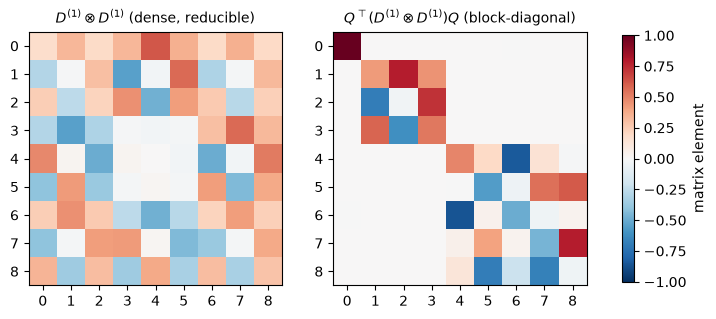

In [5]:
# Stack the three CG tensors (reshaped to 9 x (2l3+1) and rescaled by sqrt(2l3+1))
Q = torch.cat([C[l3].reshape(9, 2 * l3 + 1) * (2 * l3 + 1) ** 0.5 for l3 in (0, 1, 2)], dim=1)

# Check that Q is orthogonal
print("Q is orthogonal:", torch.allclose(Q.T @ Q, torch.eye(9)))

# Create a random rotation
R = o3.rand_matrix()

# Compute the Kronecker product of the two 1D irreps
D_kron = torch.kron(o3.Irrep(1, -1).D_from_matrix(R), o3.Irrep(1, -1).D_from_matrix(R))

# Change of basis of D^(1) x D^(1)
# Block-diagonal representation of the three irreps
D_block = Q.T @ D_kron @ Q

# Compute the direct sum of the three irreps
# Used for comparison
D_direct_sum = o3.Irreps("0e + 1e + 2e").D_from_matrix(R)        
print("Q^T (D x D) Q = D^(0) + D^(1) + D^(2):",
      torch.allclose(D_block, D_direct_sum, atol=1e-12))

# Plot the two representations of D^(1) x D^(1)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, M, title in [(axes[0], D_kron, r"$D^{(1)} \otimes D^{(1)}$ (dense, reducible)"),
                     (axes[1], D_block, r"$Q^\top (D^{(1)} \otimes D^{(1)}) Q$ (block-diagonal)")]:
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))

fig.colorbar(im, ax=axes, shrink=0.8, label="matrix element")
plt.show()

The right panel shows the block-diagonal structure: a $1{\times}1$ block ($l_3{=}0$), a $3{\times}3$ block ($l_3{=}1$), and a $5{\times}5$ block ($l_3{=}2$). The same rotation $R$ can now act on each block independently. This is what **decomposing the tensor product into irreps** means concretely.

### The parity rule $p_3 = p_1 p_2$

Under the inversion operation, $P: \vec r \mapsto -\vec r$, an irrep $(l, p)$ is multiplied by $p = \pm 1$. A product $x_{m_1} y_{m_2}$ therefore picks up the factor $p_1 p_2$: *every* $l_3$ inherits the **same** parity $p_3 = p_1 p_2$. This has a famous consequence: for two *polar* vectors (irrep $1o$, e.g. positions) the resulting tensor product yields $1o \otimes 1o = 0e \oplus 1e \oplus 2e$ where the $l_3 = 1$ part is a **pseudovector** ($1e$, *axial* vector), exactly like the physicist's cross product $\vec x \times \vec y$ (angular momentum, magnetic field). This pseudovector does *not* flip sign under inversion because the two sign flips of $x$ and $y$ cancel.

## The three paths of $1 \otimes 1$: dot, cross, and symmetric traceless outer product

The low-$l$ real CG coefficients are famous mathematical entities and deserve a special mention. In particular,

$$ C^{(0,0)}_{(1,i)(1,j)} \propto \delta_{ij}, \qquad \text{and} \qquad C^{(1,i)}_{(1,j)(1,k)} \propto \epsilon_{ijk}, $$

which correspond to the **Kronecker delta** and the **Levi-Civita symbol**, respectively. In other words, the $l_3 = 0$ path of two vectors is the **dot product** and the $l_3 = 1$ path is the **cross product**. Furthermore, the remaining $l_3 = 2$ path is the **symmetric traceless part of the outer product** $x y^\top$.

We now verify all three operations in `torch`. As mentioned, the e3nn's `wigner_3j` is normalized to unit Frobenius norm, so in each identity we have to consider an explicit constant.

In [6]:
# Two generic vectors, e3nn order (y, z, x)
x, y = torch.randn(3), torch.randn(3)

# l3 = 0 path <-> dot product:  C^(0)_ij = delta_ij / sqrt(3)
# Shape (1,)
out0 = torch.einsum("ijk,i,j->k", C[0], x, y)

# Check that the l3=0 path is indeed the dot product
print("C^(0) equals I/sqrt(3):", torch.allclose(C[0][:, :, 0], torch.eye(3) / 3**0.5))
print(f"sqrt(3) * (l3=0 path) = {3**0.5 * out0.item():+.6f}")
print(f"torch.dot(x, y)       = {torch.dot(x, y).item():+.6f}")

C^(0) equals I/sqrt(3): True
sqrt(3) * (l3=0 path) = -1.573034
torch.dot(x, y)       = -1.573034


In [7]:
# l3 = 1 path <-> cross product:  C^(1)_ijk = epsilon_ijk / sqrt(6)
# Shape (3,), still in e3nn order (y, z, x)
out1 = torch.einsum("ijk,i,j->k", C[1], x, y)

# e3nn (y, z, x)  ->  Cartesian (x, y, z)
to_cart = [2, 0, 1]

# Check that the l3=1 path is indeed the cross product
print("sqrt(6) * (l3=1 path) =", (6**0.5 * out1[to_cart]).tolist())
print("torch.cross(x, y)     =", torch.cross(x[to_cart], y[to_cart], dim=0).tolist())

sqrt(6) * (l3=1 path) = [-0.6707221450230757, -0.3104339305635142, -0.058263167725321384]
torch.cross(x, y)     = [-0.6707221450230758, -0.31043393056351426, -0.05826316772532135]


In [8]:
# l3 = 2 path <-> symmetric traceless outer product
# Full outer product x y^T
T = torch.outer(x, y)

# The symmetric traceless part
S = 0.5 * (T + T.T) - torch.eye(3) * T.trace() / 3

# Antisymmetric + trace remainder
A = T - S

# The l3 = 2 path, 5 components
out2 = torch.einsum("ijk,i,j->k", C[2], x, y)
print("C^(2) : T == C^(2) : S       :", torch.allclose(out2, torch.einsum("ijk,ij->k", C[2], S)))
print(f"C^(2) : (antisym + trace)    : {torch.einsum('ijk,ij->k', C[2], A).abs().max():.1e}")
print("|out2| == |S|_F / sqrt(5)    :", torch.allclose(out2.norm(), S.norm() / 5**0.5))

# And the change of basis is invertible: recover the 3x3 matrix S from the 5 components
S_rec = 5 * torch.einsum("ijk,k->ij", C[2], out2)
print("S recovered from 5 components:", torch.allclose(S_rec, S))

C^(2) : T == C^(2) : S       : True
C^(2) : (antisym + trace)    : 0.0e+00
|out2| == |S|_F / sqrt(5)    : True
S recovered from 5 components: True


So the CG coefficients can reproduce vector algebra exactly:

| path | output irrep | classical operation |
|---|---|---|
| $1o \otimes 1o \to 0e$ | scalar | $\vec x \cdot \vec y$ |
| $1o \otimes 1o \to 1e$ | pseudovector | $\vec x \times \vec y$ |
| $1o \otimes 1o \to 2e$ | rank-2 symmetric traceless | $\tfrac12(x y^\top + y x^\top) - \tfrac13 (\vec x \cdot \vec y)\, I$ |

The last check above also shows why the $l = 2$ irrep is 5-dimensional: a symmetric traceless $3 \times 3$ matrix has $6 - 1 = 5$ independent entries, and the CG matrix $\sqrt{5}\,C^{(2)}$ is an orthogonal map between the two descriptions.

## Selection rules at a glance

In the course utility folder, we have provided `course_utils.plotting.plot_tp_selection_rules` function which tabulates $\mathrm{ir}_1 \otimes \mathrm{ir}_2$ for every pair of input irreps: The multiplication table of $O(3)$ irreps.

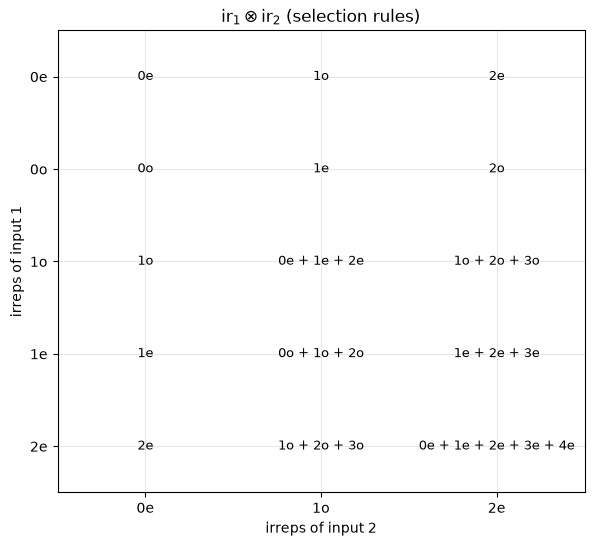

In [9]:
ax = plot_tp_selection_rules("0e + 0o + 1o + 1e + 2e", "0e + 1o + 2e")
plt.show()

In the table above, note how parities multiply ($o \times o = e$, $e \times o = o$) and how higher $l$ inputs produce wider ranges of output $l$.

## Why tensor products are the *only* equivariant bilinear maps

The tensor products are *the* central operation of equivariant networks because:

1. **They are bilinear or linear on the product space.** Any bilinear mapping, $B: V_1 \times V_2 \to V_3$, factors uniquely through the tensor-product space: $B(x, y) = L(x \otimes y)$ for a linear map $L: V_1 \otimes V_2 \to V_3$. If $B$ is equivariant, $L$ is an *intertwiner* (commutes with the group action).
2. The tensor product, $V_1 \otimes V_2$, **decomposes and splits into irreps** $\bigoplus_{l_3} V^{(l_3, p_3)}$ with the CG change of basis.
3. **Schur's lemma** (Lesson 01b): an intertwiner between two irreps is **zero** if the irreps are different and a **scalar multiple of the identity** if they are the same.

Hence every equivariant bilinear map is a *weighted sum of CG paths*: one free scalar $w$ per allowed $(l_1, l_2) \to l_3$ path, and nothing else. There is no cleverer equivariant way to multiply two features: the only freedom a network has is *which paths to use and with what weights*. That freedom is exactly what `o3.TensorProduct` in e3nn parametrizes (Lesson 03b).

Let us verify Schur's counting numerically: we solve for **all** bilinear maps $B_{ijk} x_i y_j \;(= \text{output}_k)$ from $1 \otimes 1$ into $l_3$ that commute with rotations, by finding the null space of the linear constraints $\big[D^{(1)} \otimes D^{(1)} \otimes D^{(l_3)} - I\big]\, \mathrm{vec}(B) = 0$ stacked over several random rotations. The dimension of that null space is the number of independent equivariant bilinear maps: it should be **1** for each allowed $l_3 \in \{0, 1, 2\}$ and **0** for the forbidden $l_3 = 3$.

In [10]:
# Count the number of independent equivariant bilinear maps l1 x l2 -> l3
def n_equivariant_bilinear_maps(l1, l2, l3, n_rot=8, tol=1e-10):
    '''dim of the space of rotation-equivariant bilinear maps  l1 x l2 -> l3.'''
    
    # The dimension of the space of bilinear maps is (2l1+1)(2l2+1)(2l3+1)
    dim = (2 * l1 + 1) * (2 * l2 + 1) * (2 * l3 + 1)
    
    # Loop over random rotations and stack the constraints
    rows = []
    for _ in range(n_rot):
        # Generate a random rotation
        R = o3.rand_matrix()
        
        # Compute the Wigner matrices for the three irreps
        Ds = [o3.Irrep(l, 1).D_from_matrix(R) for l in (l1, l2, l3)]
        
        # Append the constraint: D^(l1)(R) x D^(l2)(R) x D^(l3)(R) - I = 0
        rows.append(torch.kron(Ds[0], torch.kron(Ds[1], Ds[2])) - torch.eye(dim))
    
    # Null space of stacked constraints
    sing = torch.linalg.svdvals(torch.cat(rows))
    
    # Count the number of singular values that are effectively zero (within
    # tolerance)
    return int((sing < tol).sum())

# Count the number of independent equivariant bilinear maps l1 x l2 -> l3
# where l1 = l2 = 1, and l3 = 0, 1, 2, 3.
for l3 in (0, 1, 2, 3):
    
    # Compute the number of independent equivariant bilinear maps
    n = n_equivariant_bilinear_maps(1, 1, l3)
    
    # Check if the map is allowed by the triangle inequality (Eq. 5)
    allowed = "allowed" if abs(1 - 1) <= l3 <= 1 + 1 else "FORBIDDEN by Eq. (5)"
    print(f"1 x 1 -> {l3}:  {n} independent equivariant bilinear map(s)   ({allowed})")

1 x 1 -> 0:  1 independent equivariant bilinear map(s)   (allowed)
1 x 1 -> 1:  1 independent equivariant bilinear map(s)   (allowed)
1 x 1 -> 2:  1 independent equivariant bilinear map(s)   (allowed)
1 x 1 -> 3:  0 independent equivariant bilinear map(s)   (FORBIDDEN by Eq. (5))


## Equivariance check of the full CG tensor product

We assemble the complete map $(x, y) \mapsto \big((x \otimes y)^{(0)}, (x \otimes y)^{(1)}, (x \otimes y)^{(2)}\big)$ for two vector inputs and check it with `assert_equivariant`, which draws random $O(3)$ elements (rotations and inversions, so this also validates the parity assignment $1o \otimes 1o \to$ even irreps).

In [11]:
# z: (batch, 6) holding [x (1o) | y (1o)]
def cg_tensor_product(z):
    # Split the input into two vectors, x and y, each of shape (batch, 3)
    x, y = z[:, :3], z[:, 3:]
    
    # Compute the tensor product using the CG coefficients for l3 = 0, 1, 2
    return torch.cat([torch.einsum("ijk,bi,bj->bk", C[l3], x, y) for l3 in (0, 1, 2)], dim=-1)

# Check that the full CG tensor product is equivariant
assert_equivariant(cg_tensor_product, irreps_in="1o + 1o", irreps_out="0e + 1e + 2e")

equivariant!  (max error 5.329e-15 over random O(3) elements)


5.329070518200751e-15

## Summary

In this lesson, we have learned:

- The **tensor product**, $x \otimes y$ (all pairwise products), is bilinear and equivariant: it transforms with the Kronecker product $D^{(l_1)} \otimes D^{(l_2)}$, which is **reducible**.
- The **Clebsch–Gordan series**, $l_1 \otimes l_2 = |l_1 - l_2| \oplus \cdots \oplus (l_1 + l_2)$, with parity $p_3 = p_1 p_2$ lists the irreducible pieces. Each allowed $(l_3, p_3)$ is a **path**.
- The **CG coefficients**, `o3.wigner_3j(l1, l2, l3)`, enable an orthogonal change of basis and are defined by invariance under the simultaneous action of the three Wigner matrices (Eq. 7).
- For two vectors, we've identified three special paths using CG coefficients: the **dot product**, **cross product** (yielding a pseudovector), and **symmetric traceless outer product**. We have verified the operations against `torch.dot` / `torch.cross` up to the normalization constants $\sqrt 3$, $\sqrt 6$.
- **Schur's lemma** implies that the aforementioned paths exhaust *all* equivariant bilinear maps which is confirmed by a numerical null-space computation.

**Next:** In Lesson 03b we demonstrate how e3nn package can convert a weighted sums of paths into learnable layers using `o3.TensorProduct`, `o3.FullyConnectedTensorProduct`, connection modes, and weight counting.

## Exercises

**Exercise 1: Hands-on with the selection rules.** Decompose $2e \otimes 1o$ using Eq. (5) (values of $l_3$ and the parity), check the dimension count, then verify with `o3.Irrep("2e") * o3.Irrep("1o")`.

<details><summary>Solution</summary>

$|2-1| \le l_3 \le 2+1 \Rightarrow l_3 \in \{1, 2, 3\}$ and $p_3 = e \cdot o = o$, so $2e \otimes 1o = 1o \oplus 2o \oplus 3o$. Dimensions: $5 \times 3 = 15 = 3 + 5 + 7$.

```python
# Test the tensor product
# [1o, 2o, 3o]
print(list(o3.Irrep("2e") * o3.Irrep("1o")))
```
</details>

**Exercise 2: Symmetry of the paths.** Using the `C[l3]` tensors, show numerically that the $l_3 = 0$ and $l_3 = 2$ outputs of $1 \otimes 1$ are *symmetric* under swapping $x \leftrightarrow y$ while the $l_3 = 1$ output is *antisymmetric*. Which classical identities do these correspond to?

<details><summary>Solution</summary>

```python
# Create two random vectors
x, y = torch.randn(3), torch.randn(3)

# Check symmetry and antisymmetry of the three paths
for l3 in (0, 1, 2):
    xy = torch.einsum("ijk,i,j->k", C[l3], x, y)
    yx = torch.einsum("ijk,i,j->k", C[l3], y, x)
    print("l3 =", l3, "symmetric:", torch.allclose(xy, yx), " antisymmetric:", torch.allclose(xy, -yx))
```

This symmetry structure is why $x \otimes x$ has no $l_3 = 1$ part: the cross product of a vector with itself vanishes. </details>

**Exercise 3: Schur counting for higher irreps.** With `n_equivariant_bilinear_maps`, count the equivariant bilinear maps $2 \otimes 1 \to l_3$ for $l_3 = 0, \dots, 4$. Where is the count 1 and where 0? Reconcile with Eq. (5).

<details><summary>Solution</summary>

```python
# Count the number of independent equivariant bilinear maps 2 x 1 -> l3
for l3 in range(5):
    print(l3, n_equivariant_bilinear_maps(2, 1, l3))
```

Counts: $l_3 \in \{0, 4\} \to 0$, and $l_3 \in \{1, 2, 3\} \to 1$. These ranges exactly correspond to $|2-1| \le l_3 \le 2+1$ from Eq. (5). (Parity adds no constraint here because we tested rotations only. Over the full $O(3)$ each surviving path carries parity $p_3 = p_1 p_2$.) </details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)